# Mansonia genome assemblies: can they feed S2F?

**Goal.** Inspect the two post-assembly genome files in
`data/mansonia/genoma_Mansonia_pos_montagem/` (*Mansonia humeralis* and *Mansonia titillans*)
and decide whether they can be used as input to the S2F protein function prediction pipeline.

**Why this matters.** S2F predicts GO terms **per protein**. Every S2F stage works on amino-acid sequences:

| S2F stage | What it consumes |
|---|---|
| `[configuration] fasta` in the run config (e.g. `conf/mansonia_titillans.conf`) | a **protein** FASTA |
| InterPro seed (`interpro_output = compute`) | InterProScan on protein sequences |
| HMMER seed (`hmmer_output = compute`) | `phmmer`/`hmmer` of the proteins against UniProt-SwissProt |
| Homology graph / graph collection | BLASTP of the proteins against STRING v12 protein sequences, used to transfer interactions |

A genome assembly is a set of **DNA contigs**. It does not list genes or proteins. So the question this notebook
answers is: *what exactly is in these files, how good are they as assemblies, and what steps are missing between them
and a protein FASTA that S2F can use?*

External context used here (checked 2026-09-28):
- No nuclear genome assembly for any *Mansonia* species is in NCBI Datasets (`genome/taxon/Mansonia` returns an
  empty report). Only mitochondrial genomes are public, e.g. *Ma. uniformis* (15.6 kb, 13 protein-coding genes;
  PMC7748744). These assemblies are therefore likely the **first nuclear genomes** for these species.
- Karyotype: both species are 2n = 6 (XX, II, III). *Ma. humeralis* has centromeric/pericentromeric heterochromatin,
  *Ma. titillans* has weak or none; the samples came from around the Jirau dam, Rondonia, Brazil (PMC9991104).
- Contig names `ptg######l` / `ptg######c` are **hifiasm** primary contigs (`l` = linear, `c` = circular),
  which means the input was PacBio HiFi long reads. `purged` in the filename suggests purge_dups / purge_haplotigs removed
  haplotypic duplicates. The meaning of `posCBS` could not be confirmed and should be checked with the data provider.


## 1. Paths and provenance

In [1]:
import datetime as dt
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

S2F_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
GENOME_DIR = S2F_ROOT / 'data' / 'mansonia' / 'genoma_Mansonia_pos_montagem'
CANDIDATE_DIR = S2F_ROOT / 'data' / 'mansonia' / 'mansonia_candidate_proteins'
EXPORT_DIR = S2F_ROOT / 'notebooks' / 'exports' / 'mansonia_genome_check'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

GENOMES = {
    'humeralis': GENOME_DIR / 'genome_purged_Ma_humeralis_posCBS.fasta',
    'titillans': GENOME_DIR / 'genome_purged_Ma_titillans_posCBS.fasta',
}

print('date       :', dt.datetime.now().isoformat(timespec='seconds'))
print('interpreter:', sys.executable)
print('S2F root   :', S2F_ROOT)
for sp, p in GENOMES.items():
    print(f'{sp:10s}: {p}  ({p.stat().st_size / 1e9:.2f} GB on disk)')

date       : 2026-09-28T12:02:28
interpreter: /home/marcelo_baez/anaconda3/bin/python
S2F root   : /home/marcelo_baez/paccanaro-lab/PFP-Research/S2F
humeralis : /home/marcelo_baez/paccanaro-lab/PFP-Research/S2F/data/mansonia/genoma_Mansonia_pos_montagem/genome_purged_Ma_humeralis_posCBS.fasta  (2.84 GB on disk)
titillans : /home/marcelo_baez/paccanaro-lab/PFP-Research/S2F/data/mansonia/genoma_Mansonia_pos_montagem/genome_purged_Ma_titillans_posCBS.fasta  (3.35 GB on disk)


/home/marcelo_baez/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/marcelo_baez/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/tmp/ipykernel_2813359/873000839.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 2. One streaming pass over each FASTA

The files are 2.8 GB and 3.4 GB, so they are read line by line. Only per-contig counts are kept in memory. For each contig
we record its length, base composition, `N` (gap) count, **lowercase** (soft-masked) bases, and any character outside `ACGTN`.
Amino-acid letters would show up in that last count, so it also tests whether the file contains protein sequences.
The results are cached as TSV files in `notebooks/exports/mansonia_genome_check/`, so re-running the notebook is fast.
Delete the cache to force a new scan.

In [2]:
NUC = b'ACGTNacgtn'


def scan_fasta(path):
    rows = []
    name, chunks = None, []

    def flush():
        if name is None:
            return
        seq = b''.join(chunks)
        up = seq.upper()
        rows.append({
            'contig': name,
            'length': len(seq),
            'A': up.count(b'A'), 'C': up.count(b'C'), 'G': up.count(b'G'), 'T': up.count(b'T'),
            'N': up.count(b'N'),
            'lowercase': len(seq) - sum(seq.count(c) for c in (b'A', b'C', b'G', b'T', b'N')) - len(seq.translate(None, NUC)),
            'non_ACGTN': len(seq.translate(None, NUC)),
        })

    with open(path, 'rb') as fh:
        for line in fh:
            if line.startswith(b'>'):
                flush()
                name, chunks = line[1:].strip().decode(), []
            else:
                chunks.append(line.rstrip(b'\r\n'))
    flush()
    return pd.DataFrame(rows)


stats = {}
for sp, path in GENOMES.items():
    cache = EXPORT_DIR / f'{sp}_contig_stats.tsv'
    if cache.exists() and cache.stat().st_mtime > path.stat().st_mtime:
        stats[sp] = pd.read_csv(cache, sep='\t')
        print(f'{sp}: loaded cache {cache.name}')
    else:
        t0 = dt.datetime.now()
        stats[sp] = scan_fasta(path)
        stats[sp].to_csv(cache, sep='\t', index=False)
        print(f'{sp}: scanned in {(dt.datetime.now() - t0).seconds}s -> {cache.name}')
    df = stats[sp]
    df['GC'] = (df['G'] + df['C']) / (df['length'] - df['N']).clip(lower=1)
    df['softmasked_frac'] = df['lowercase'] / df['length']

humeralis: loaded cache humeralis_contig_stats.tsv
titillans: loaded cache titillans_contig_stats.tsv


## 3. What kind of sequence is in the files?

In [3]:
rows = []
for sp, df in stats.items():
    L = df['length'].sum()
    rows.append({
        'species': sp,
        'n_sequences': len(df),
        'total_bp': L,
        'non_ACGTN_chars': int(df['non_ACGTN'].sum()),
        'N_bases': int(df['N'].sum()),
        'N_frac': df['N'].sum() / L,
        'softmasked_bp': int(df['lowercase'].sum()),
        'GC_overall': (df['G'].sum() + df['C'].sum()) / (L - df['N'].sum()),
    })
content = pd.DataFrame(rows).set_index('species')
content

,n_sequences,total_bp,non_ACGTN_chars,N_bases,N_frac,softmasked_bp,GC_overall
species,,,,,,,
humeralis,31795,2796452225,0,0,0.0,0,0.377583
titillans,19412,3298974418,0,0,0.0,0,0.355772


How to read this:
- `non_ACGTN_chars = 0` means the files contain **only nucleotides**: no proteins, no IUPAC ambiguity codes, no amino acids.
- `N_bases` is the number of scaffolding gaps. hifiasm writes gap-free contigs, so a value near 0 means the files are **contigs, not
  Hi-C scaffolds**. That fits the `ptg` names.
- `softmasked_bp` is the number of lowercase bases. Zero means **repeats have not been masked yet**. Repeat masking is needed before gene
  prediction, especially in mosquito genomes that are large and full of transposable elements.

## 4. Contig naming: hifiasm primary contigs, circular contigs, and split pieces

In [4]:
import re

pat = re.compile(r'^lcl\|ptg(\d+)([lc])(?:_(\d+))?$')
for sp, df in stats.items():
    m = df['contig'].str.extract(pat)
    df['ptg_id'] = m[0]
    df['topology'] = m[1].map({'l': 'linear', 'c': 'circular'})
    df['piece'] = m[2]
    df['parent'] = 'ptg' + m[0] + m[1]
    unparsed = m[0].isna().sum()
    pieces_per_parent = df.groupby('parent').size()
    print(f'--- {sp}')
    print('  unparsed headers           :', unparsed)
    print('  topology counts            :', df['topology'].value_counts().to_dict())
    print('  headers with _N suffix     :', df['piece'].notna().sum())
    print('  parent contigs split in >1 :', (pieces_per_parent > 1).sum(), 'parents')
    circ = df[df['topology'] == 'circular'][['contig', 'length', 'GC']]
    print('  circular contigs (candidate mitogenome / symbiont):')
    print(circ.to_string(index=False))

--- humeralis
  unparsed headers           : 0
  topology counts            : {'linear': 31794, 'circular': 1}
  headers with _N suffix     : 31624
  parent contigs split in >1 : 21 parents
  circular contigs (candidate mitogenome / symbiont):
          contig  length       GC
lcl|ptg036316c_1   10406 0.369787
--- titillans
  unparsed headers           : 0
  topology counts            : {'linear': 19410, 'circular': 2}
  headers with _N suffix     : 19313
  parent contigs split in >1 : 7 parents
  circular contigs (candidate mitogenome / symbiont):
          contig  length       GC
lcl|ptg038508c_1   35623 0.354771
lcl|ptg038586c_1   12205 0.503073


Notes:
- **Circular contigs.** A mosquito mitogenome is about 15-16 kb and very AT-rich (GC around 0.2); the *Ma. uniformis* mitogenome is 15,603 bp.
  None of the circular contigs found (humeralis: 10.4 kb, GC 0.37; titillans: 35.6 kb, GC 0.35 and 12.2 kb, GC 0.50) matches that profile.
  So the mitogenome was probably **removed or never circularised**, and these circular contigs should be identified (BLAST) before annotation.
  The 12.2 kb contig with GC 0.50 is the most likely non-mosquito sequence.
- Most headers end in `_1`, and a few parent contigs appear as `_1`, `_2`, ... This is what a contamination or adaptor screen does when it
  **splits or trims** a contig (for example NCBI FCS). It may also be what `posCBS` refers to. The processing step should be
  confirmed with the people who produced the assembly.

## 5. Assembly contiguity

In [5]:
def nx(lengths, x):
    s = np.sort(np.asarray(lengths))[::-1]
    c = np.cumsum(s)
    i = np.searchsorted(c, c[-1] * x / 100)
    return int(s[i]), int(i + 1)


rows = []
for sp, df in stats.items():
    L = df['length']
    n50, l50 = nx(L, 50)
    n90, l90 = nx(L, 90)
    rows.append({
        'species': sp,
        'total_Gb': L.sum() / 1e9,
        'n_contigs': len(L),
        'largest_Mb': L.max() / 1e6,
        'N50_Mb': n50 / 1e6, 'L50': l50,
        'N90_Mb': n90 / 1e6, 'L90': l90,
        'contigs_>=1Mb': int((L >= 1e6).sum()),
        'bp_in_>=1Mb_%': 100 * L[L >= 1e6].sum() / L.sum(),
        'contigs_<10kb': int((L < 1e4).sum()),
        'median_kb': L.median() / 1e3,
    })
contiguity = pd.DataFrame(rows).set_index('species')
contiguity.to_csv(EXPORT_DIR / 'assembly_contiguity.tsv', sep='\t')
contiguity.round(3)

,total_Gb,n_contigs,largest_Mb,N50_Mb,L50,N90_Mb,L90,contigs_>=1Mb,bp_in_>=1Mb_%,contigs_<10kb,median_kb
species,,,,,,,,,,,
humeralis,2.796,31795,2.097,0.139,6063,0.039,21041,10,0.520,0,56.736
titillans,3.299,19412,1.877,0.257,4173,0.092,11822,31,1.129,0,144.714


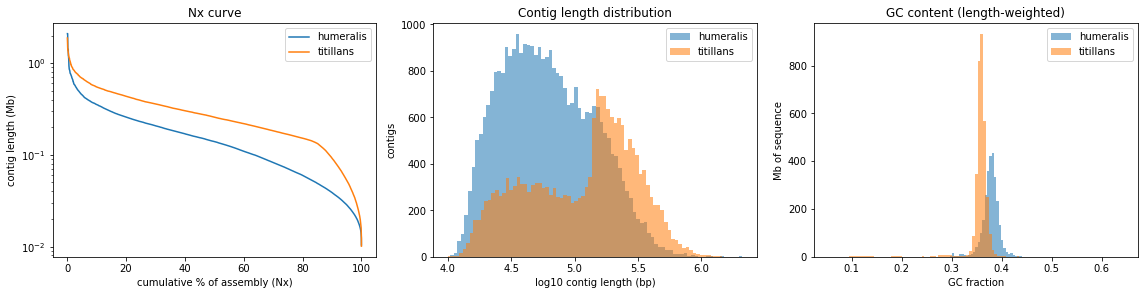

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for sp, df in stats.items():
    s = np.sort(df['length'].values)[::-1]
    axes[0].plot(100 * np.cumsum(s) / s.sum(), s / 1e6, label=sp)
    axes[1].hist(np.log10(df['length']), bins=80, alpha=0.55, label=sp)
    axes[2].hist(df['GC'], bins=100, weights=df['length'] / 1e6, alpha=0.55, label=sp)
axes[0].set(xlabel='cumulative % of assembly (Nx)', ylabel='contig length (Mb)', yscale='log', title='Nx curve')
axes[1].set(xlabel='log10 contig length (bp)', ylabel='contigs', title='Contig length distribution')
axes[2].set(xlabel='GC fraction', ylabel='Mb of sequence', title='GC content (length-weighted)')
for ax in axes:
    ax.legend()
plt.tight_layout()
fig.savefig(EXPORT_DIR / 'assembly_overview.png', dpi=130)
plt.show()

Reference points for sizes:
- The ***Aedes aegypti* AaegL5** reference is about **1.28 Gb** in 3 chromosomes (Matthews et al., 2018, *Nature*). Culicine genomes are large because of transposable elements.
- *Culex quinquefasciatus* and *Anopheles gambiae* genomes are much smaller, roughly 0.5-0.6 Gb and about 0.26 Gb.

**Observed:** 2.80 Gb (humeralis) and 3.30 Gb (titillans). That is more than twice the size of *Ae. aegypti*, split into 19-32k contigs with
N50 of only 0.14 / 0.26 Mb and fewer than 1.2% of bases in contigs of 1 Mb or more. For HiFi data this is **fragmented**. The karyotype data points the
other way: *Ma. humeralis* has the *longer* haploid chromosome complement (33.1 um vs 28.9 um), yet its assembly is the *smaller* one. Because
of this, the titillans assembly in particular may still carry duplicated haplotypes.

If the totals above are much larger than expected for a haploid mosquito genome, the "purged" assembly may still contain **haplotypic duplication**
(alternative alleles of the same region) or contamination. That would **inflate the gene count**: the same protein would be predicted twice and would
look like a paralog. This matters for S2F because duplicated proteins would link to each other in the homology graph. **BUSCO (`diptera_odb10`) duplicated %**
and a k-mer genome size estimate (GenomeScope on the HiFi reads) are the standard ways to check.

## 6. Contigs with unusual GC (possible contaminants or organelles)

In [7]:
for sp, df in stats.items():
    gc_med = np.average(df['GC'], weights=df['length'])
    mad = np.median(np.abs(df['GC'] - gc_med))
    df['GC_outlier'] = (np.abs(df['GC'] - gc_med) > 6 * max(mad, 0.005)) & (df['length'] >= 5_000)
    out = df[df['GC_outlier']]
    print(f'{sp}: length-weighted GC {gc_med:.3f}; {len(out)} GC-outlier contigs >=5 kb '
          f'({out["length"].sum() / 1e6:.2f} Mb)')
    print(out.sort_values('length', ascending=False)[['contig', 'length', 'GC', 'topology']].head(10).to_string(index=False))
    print()

humeralis: length-weighted GC 0.378; 860 GC-outlier contigs >=5 kb (29.54 Mb)
          contig  length       GC topology
lcl|ptg000968l_1  911320 0.303388   linear
lcl|ptg006878l_1  510527 0.468083   linear
lcl|ptg021247l_1  461027 0.261102   linear
lcl|ptg022675l_1  246448 0.309842   linear
lcl|ptg010559l_1  190068 0.314135   linear
lcl|ptg019073l_1  165260 0.243810   linear
lcl|ptg014160l_1  152958 0.257750   linear
lcl|ptg031302l_1  136758 0.483028   linear
lcl|ptg007404l_1  127680 0.305475   linear
lcl|ptg003043l_1  126605 0.462667   linear

titillans: length-weighted GC 0.356; 839 GC-outlier contigs >=5 kb (105.88 Mb)
          contig  length       GC topology
lcl|ptg000766l_1 1594728 0.290140   linear
lcl|ptg001368l_1 1499856 0.296643   linear
lcl|ptg001918l_1 1399483 0.290073   linear
lcl|ptg003701l_1 1362488 0.431089   linear
lcl|ptg000293l_1 1188341 0.278017   linear
lcl|ptg000573l_1 1157131 0.311018   linear
lcl|ptg000056l_1 1139791 0.278022   linear
lcl|ptg013118l_1 1071278 

GC outliers are only a hint. A proper check (BlobToolKit or NCBI FCS-GX) combines taxonomic hits with read coverage. Any bacterial or
*Wolbachia* contigs that remain would produce **non-mosquito proteins** in the proteome, and S2F would give them GO terms as if they were *Mansonia* genes.

## 7. Link to the candidate proteins already used in S2F runs

The earlier S2F runs `mansonia_humeralis` / `mansonia_titillans` (`conf/mansonia_*.conf`) used
`data/mansonia/mansonia_candidate_proteins/*/*_all_categories_protein.cleaned.faa`. These are **283 targeted proteins per species**,
extracted by homology to *Aedes*, *Culex* and *Anopheles* reference proteins, in five categories (tracheal/spiracle, cuticle/chitin, hypoxia
signalling, chemosensory, mechanosensory). This cell checks that their loci refer to contigs in these genome files, i.e. that the
candidate set was derived from the same assemblies.

In [8]:
for sp, df in stats.items():
    summ_path = CANDIDATE_DIR / sp / f'{sp}_extraction_summary.tsv'
    if not summ_path.exists():
        print(f'{sp}: no extraction summary at {summ_path}')
        continue
    summ = pd.read_csv(summ_path, sep='\t')
    summ['contig'] = summ['locus'].str.extract(r'^(lcl\|ptg\d+[lc](?:_\d+)?)')[0]
    found = summ['contig'].isin(set(df['contig']))
    print(f'--- {sp}: {len(summ)} candidate loci, {found.sum()} on contigs present in the genome file '
          f'({summ["contig"].nunique()} distinct contigs)')
    print(summ.groupby('category').agg(n=('locus', 'size'),
                                       median_identity=('identity', 'median'),
                                       median_len=('protein_len', 'median'),
                                       with_internal_stops=('internal_stops', lambda s: int((s > 0).sum())))
          .to_string())
    print('best-hit species:', summ['best_hit_species'].value_counts().to_dict())

--- humeralis: 283 candidate loci, 283 on contigs present in the genome file (257 distinct contigs)
                       n  median_identity  median_len  with_internal_stops
category                                                                  
1_tracheal_spiracle    7          0.77430       563.0                    0
2_cuticle_chitin     175          0.73330       140.0                    3
3_hypoxia_signaling    6          0.64315       631.5                    1
4_chemosensory        78          0.57020       363.5                    7
5_mechanosensory      17          0.77370       901.0                    1
best-hit species: {'Aedes_aegypti': 134, 'Culex_quinquefasciatus': 115, 'Anopheles_gambiae': 34}
--- titillans: 283 candidate loci, 283 on contigs present in the genome file (240 distinct contigs)
                       n  median_identity  median_len  with_internal_stops
category                                                                  
1_tracheal_spiracle    9    

These 283 proteins are only a **small targeted subset** of the proteome. A mosquito genome encodes about 13,000-20,000 protein-coding genes
(e.g. *Ae. aegypti* AaegL5 has about 14.6k). Running S2F on the full genome needs a genome-wide gene annotation.

## 8. S2F readiness summary

In [9]:
checks = []
for sp, df in stats.items():
    c = content.loc[sp]
    checks += [
        (sp, 'File contains protein sequences', 'NO' if c['non_ACGTN_chars'] == 0 else 'check', 'S2F needs a protein FASTA'),
        (sp, 'Gene models (GFF/GTF) provided', 'NO', 'no annotation file in genoma_Mansonia_pos_montagem/'),
        (sp, 'Repeats soft-masked', 'NO' if c['softmasked_bp'] == 0 else f"{c['softmasked_bp'] / c['total_bp']:.1%}", 'needed before gene prediction'),
        (sp, 'Contig-level assembly (no gaps)', 'yes' if c['N_bases'] == 0 else f"{int(c['N_bases'])} N", 'fine for annotation'),
        (sp, 'N50 (Mb)', f"{contiguity.loc[sp, 'N50_Mb']:.2f}", 'mosquito genes often span tens of kb; a short N50 splits genes across contigs'),
        (sp, 'Total size (Gb)', f"{contiguity.loc[sp, 'total_Gb']:.2f}", 'compare with k-mer estimate / BUSCO duplication'),
    ]
readiness = pd.DataFrame(checks, columns=['species', 'check', 'value', 'why it matters'])
readiness.to_csv(EXPORT_DIR / 's2f_readiness.tsv', sep='\t', index=False)
readiness

,species,check,value,why it matters
0,humeralis,File contains protein sequences,NO,S2F needs a protein FASTA
1,humeralis,Gene models (GFF/GTF) provided,NO,no annotation file in genoma_Mansonia_pos_mont...
2,humeralis,Repeats soft-masked,NO,needed before gene prediction
3,humeralis,Contig-level assembly (no gaps),yes,fine for annotation
4,humeralis,N50 (Mb),0.14,mosquito genes often span tens of kb; a short ...
5,humeralis,Total size (Gb),2.80,compare with k-mer estimate / BUSCO duplication
6,titillans,File contains protein sequences,NO,S2F needs a protein FASTA
7,titillans,Gene models (GFF/GTF) provided,NO,no annotation file in genoma_Mansonia_pos_mont...
8,titillans,Repeats soft-masked,NO,needed before gene prediction
9,titillans,Contig-level assembly (no gaps),yes,fine for annotation


## 9. Conclusion and path to an S2F run

**Can these files be used directly in S2F?** **No.** They are nucleotide genome assemblies (hifiasm primary contigs, purged, apparently
screened). They contain no gene models or protein sequences, and S2F's `fasta`, InterPro, HMMER and STRING-homology stages all need proteins.

**Are they useful for S2F?** **Yes, as the source for a proteome, with caveats.** They are accurate long-read (HiFi) contigs with no gaps
and no ambiguity codes, so predicted proteins should have few frame errors. However, contiguity is modest (N50 0.14 Mb humeralis / 0.26 Mb titillans),
and several candidate loci already span 30-60 kb of genomic sequence. Some genes will therefore be **split across contigs**, giving
fragmented or partial proteins. The total sizes (2.8 / 3.3 Gb) also need checking for leftover duplication. The existing 283-protein candidate
sets show the extraction works: all 283 loci per species fall on contigs in these files, and only a few have internal stops. The absence of any public nuclear *Mansonia* genome also fits S2F's use case well: a newly sequenced organism with
no experimental GO annotations. S2F's predictions would then serve as **ranked functional hypotheses** to prioritize experimental validation,
not as final annotations.

**Missing steps (genome to S2F input):**
1. **Assembly QC (first priority, given the size and N50)**: BUSCO `diptera_odb10` in genome mode, to measure completeness and duplication. Also check contamination and organelles (FCS-GX / BlobToolKit) and set aside the
   mitochondrial contig.
2. **Repeat masking**: build a species-specific library (RepeatModeler2 or EarlGrey), then soft-mask with RepeatMasker.
3. **Gene prediction**: BRAKER3 (RNA-seq + OrthoDB Arthropoda proteins) if RNA-seq exists; otherwise BRAKER2/GALBA or miniprot with
   *Ae. aegypti* / *Cx. quinquefasciatus* / *An. gambiae* proteomes. The candidate-protein extraction already used these references.
4. **Proteome extraction**: `gffread -y`, keep one isoform per gene (the longest), remove internal stops and the trailing `*`
   (as done for `*_all_categories_protein.cleaned.faa`), then run BUSCO in protein mode.
5. **S2F**: point `[configuration] fasta` in a new run config (e.g. `conf/mansonia_<sp>_proteome.conf`) at the cleaned proteome, and run
   `python3 S2F.py predict --run-config ...`. Expect about 15-20k proteins instead of 283, so InterProScan / HMMER / BLAST against STRING will take much
   longer than the candidate runs.

**Questions for the data provider:** what `posCBS` means; whether RNA-seq or Iso-Seq exists for either species; whether a gene annotation
(GFF) is already in progress; and the k-mer genome size estimates.